#**DIA 1 - Hidrología & Modelación en WEAP (SEI)**

El modelo hidrologico de humedad de suelo en WEAP, permite interactuar con los parametros previamente descritos en la ventana de **"Data"**, como se ve en la siguiente grafica.

<img src="https://drive.google.com/uc?export=view&id=15tochn9JW6Ch8yMeyvahEPbSodrwgm8B" alt="Drawing"  width="900" style="width: 100px;"/>

A continuacion exploramos los datos para alimentar el modelo:


##Informacion de cobertura y suelo

In [ ]:
!pip install -q gdown xarray netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 31.3 MB/s eta 0:00:00


In [ ]:
import re
from pathlib import Path

import gdown
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

# Enlace compartido del .nc
url = "https://drive.google.com/file/d/1mboTlNogt9G_TfRbX6I4XyMoByy6_hlq/view?usp=sharing"
destino = "/content/Soil_LandUse.nc"

gdown.download(url, destino, quiet=False, fuzzy=True)

ds = xr.open_dataset(destino)
print(ds)

Downloading...
From: https://drive.google.com/uc?id=1mboTlNogt9G_TfRbX6I4XyMoByy6_hlq
To: /content/Soil_LandUse.nc
100%|██████████| 7.11M/7.11M [00:00<00:00, 63.7MB/s]


<xarray.Dataset> Size: 13MB
Dimensions:         (lat: 1431, lon: 1145)
Coordinates:
  * lat             (lat) float64 11kB -14.06 -14.06 -14.06 ... -20.01 -20.01
  * lon             (lon) float64 9kB -71.12 -71.11 -71.11 ... -66.35 -66.35
Data variables:
    Soil_LandCover  (lat, lon) float64 13MB ...
Attributes:
    Conventions:      CF-1.0
    Source_Software:  Esri ArcGIS


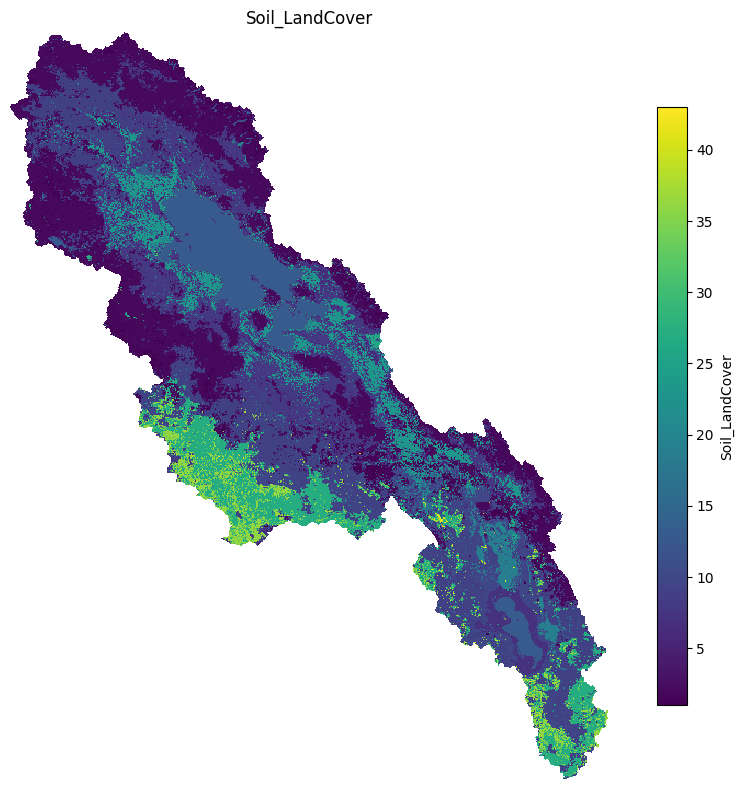

In [ ]:
da = ds["Soil_LandCover"].squeeze(drop=True)
vals = np.ma.masked_invalid(da.values)

if vals.ndim == 3:          # por si quedó una dimensión de tiempo
    vals = vals[0]

codigos = np.unique(vals.compressed())

fig, ax = plt.subplots(figsize=(10, 8))

if len(codigos) <= 30:      # códigos de clase: un color por valor
    codigos = codigos.astype(int)
    base = plt.get_cmap("tab20").colors
    cmap = ListedColormap([base[i % len(base)] for i in range(len(codigos))])
    bounds = np.array(list(codigos) + [codigos[-1] + 1]) - 0.5
    norm = BoundaryNorm(bounds, cmap.N)
    ax.imshow(vals, cmap=cmap, norm=norm, interpolation="nearest")
    ax.legend(
        handles=[
            Patch(facecolor=cmap(i), edgecolor="black", label=str(c))
            for i, c in enumerate(codigos)
        ],
        title="Soil_LandCover",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
    )
else:                       # muchos valores distintos: escala continua
    im = ax.imshow(vals, cmap="viridis", interpolation="nearest")
    fig.colorbar(im, ax=ax, label="Soil_LandCover", shrink=0.8)

ax.set_title("Soil_LandCover")
ax.set_axis_off()
fig.tight_layout()
plt.show()

Los datos proviene de una combinacion de informacion de tipos de suelo y de uso de suelo que corresponden a diversas fuentes de informacion disponibles para el area de estudio:

Tipo de Suelo:

<img src="https://drive.google.com/uc?export=view&id=1tiQ-LF3xcKzAcA8jJw-fJet_U1f_F3Ii" alt="Drawing"  width="600" style="width: 100px;"/>

Uso de Suelo:

<img src="https://drive.google.com/uc?export=view&id=12rNvRmdn6M8uMHzH6SVn2IgYCrrtiyvi" alt="Drawing"  width="600" style="width: 100px;"/>

Los datos procesados en formato GIS por lo general son producidos con valores numericos (en nuestro caso float64). Durante el procesamiento de combinacion de las capas de tipo y uso del suelo, se requiere hacer el seguimiento sobre lo que cada valor numerico producido implica. Para la modelacion en WEAP se debe contar con la relacion de la informacion numerica de la data GIS y su significado.

En la siguiente tabla se presenta el seguimiento de la data GIS mostrada previamente:

In [ ]:
from IPython.core.display import display, HTML
# Google Drive file ID
file_id = "1OttxBGi1DvGrC2Ds_8wGnga2Le5hpxFw"
embed_url = f"https://drive.google.com/file/d/{file_id}/preview"
# Define the HTML content with a resizable iframe
html_content = f"""<!DOCTYPE html><html><head><style>.resizable {{resize: vertical;overflow: auto;width: 100%;border: 1px solid black;}}</style></head><body><div class="resizable" style="height: 400px;"><iframe src="{embed_url}" width="100%" height="100%" frameborder="0"></iframe>
</div><p>If the file does not load, <a href="https://drive.google.com/file/d/{file_id}/view?usp=sharing" target="_blank">click here to view it on Google Drive</a>.</p></body></html>"""
# Display the HTML content in the notebook
display(HTML(html_content))

Para el modelo WEAP se requiere descargar los siguientes archivos:

In [3]:
from IPython.core.display import display, HTML
# Google Drive file ID
file_id = "1mboTlNogt9G_TfRbX6I4XyMoByy6_hlq"
embed_url = f"https://drive.google.com/file/d/{file_id}/preview"
# Define the HTML content with a resizable iframe
html_content = f"""<!DOCTYPE html><html><head><style>.resizable {{resize: vertical;overflow: auto;width: 100%;border: 1px solid black;}}</style></head><body><div class="resizable" style="height: 200px;"><iframe src="{embed_url}" width="100%" height="100%" frameborder="0"></iframe>
</div><p>If the file does not load, <a href="https://drive.google.com/file/d/{file_id}/view?usp=sharing" target="_blank">click here to view it on Google Drive</a>.</p></body></html>"""
# Display the HTML content in the notebook
display(HTML(html_content))

In [4]:
from IPython.core.display import display, HTML
# Google Drive file ID
file_id = "1iuJtqzfukeDUKttSzZtIGkQ7lFrCdd7c"
embed_url = f"https://drive.google.com/file/d/{file_id}/preview"
# Define the HTML content with a resizable iframe
html_content = f"""<!DOCTYPE html><html><head><style>.resizable {{resize: vertical;overflow: auto;width: 100%;border: 1px solid black;}}</style></head><body><div class="resizable" style="height: 200px;"><iframe src="{embed_url}" width="100%" height="100%" frameborder="0"></iframe>
</div><p>If the file does not load, <a href="https://drive.google.com/file/d/{file_id}/view?usp=sharing" target="_blank">click here to view it on Google Drive</a>.</p></body></html>"""
# Display the HTML content in the notebook
display(HTML(html_content))

Los archivos descritos previamente, deben ser descargados y copiados en una carpeta del proyecto para proceder con su lectura desde WEAP para configurar la opcion de **LandCover**. En la siguiente figura se describen los pasos para realizar este procedimiento:

<img src="https://drive.google.com/uc?export=view&id=1nJOljL1jlKtc2rqS9wK19iFEOAqR9xF7" alt="Drawing"  width="900" style="width: 100px;"/>

Una vez realizados estos cambios, se debe hacer una modificacion directarmente en el archivo de configuracion del proyecto en el archivo **"Area.ini"** localizado en la carpeta del proyecto, en **WEAP Areas**. La serie de pasos para hacer la modificacion es la siguiente:

<img src="https://drive.google.com/uc?export=view&id=1xdNdRPnbHRT_SYYaBVzGJeIJyMKGF3of" alt="Drawing"  width="900" style="width: 100px;"/>

Finalmente verificamos que los datos con los cambios realizados hayan sido asimilados en el modelo, en WEAP. Esto se hace en la opcion **"Data"** de WEAP

<img src="https://drive.google.com/uc?export=view&id=1BGW-siryrdp4I8Jp2yqT8tuy0p6qRQgU" alt="Drawing"  width="900" style="width: 100px;"/>